# Lab Segmentation 2

In [6]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
def getThreshold(gray_img: np.ndarray):
    img = gray_img.copy()
    img = (img * 255).astype(np.uint8)

    # Counts array
    counts = np.unique(img.flatten(), return_counts=True)
    grey_levels = counts[0]
    pixel_counts = counts[1]
    
    # Tinit
    weighted_sum = np.sum(grey_levels * pixel_counts)
    cumsum = np.cumsum(pixel_counts)
    total_pixels = cumsum[-1]
    T = round(weighted_sum / total_pixels)
    
    while True:
        # Two weighted averages
        lower_mask = grey_levels < T
        lower_levels = grey_levels[lower_mask]
        lower_counts = pixel_counts[lower_mask]
        if len(lower_counts) > 0:
            lower_mean = np.sum(lower_levels * lower_counts) / np.sum(lower_counts)
        else:
            lower_mean = 0
        
        higher_mask = grey_levels > T
        higher_levels = grey_levels[higher_mask]
        higher_counts = pixel_counts[higher_mask]
        if len(higher_counts) > 0:
            higher_mean = np.sum(higher_levels * higher_counts) / np.sum(higher_counts)
        else:
            higher_mean = 0
        
        new_T = round((lower_mean + higher_mean) / 2)
        
        if new_T == T:
            break
        T = new_T
    
    return T

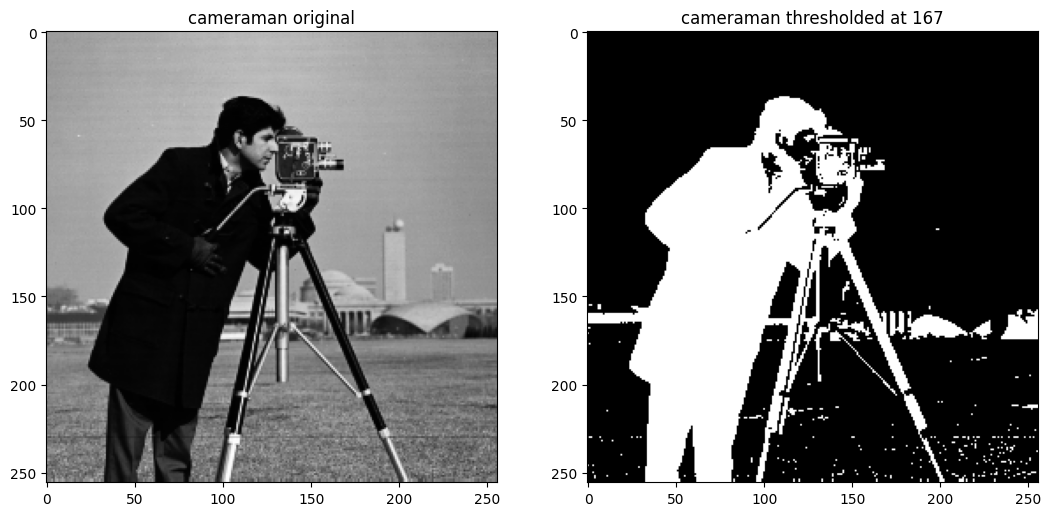

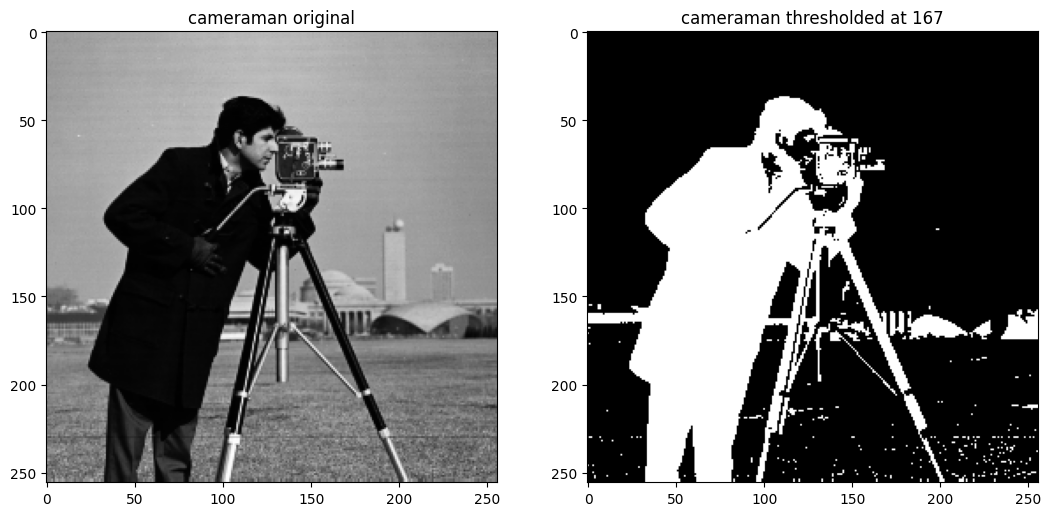

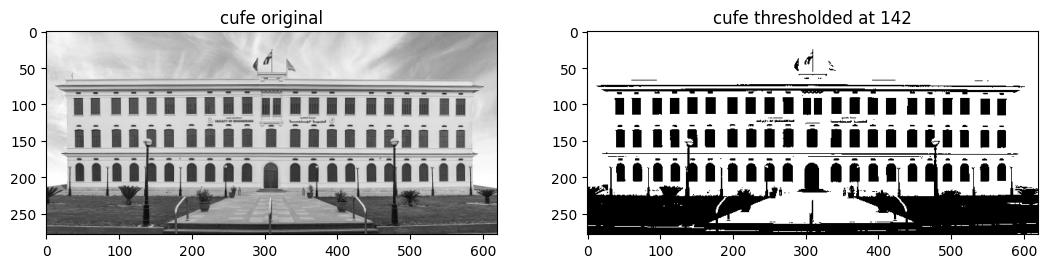

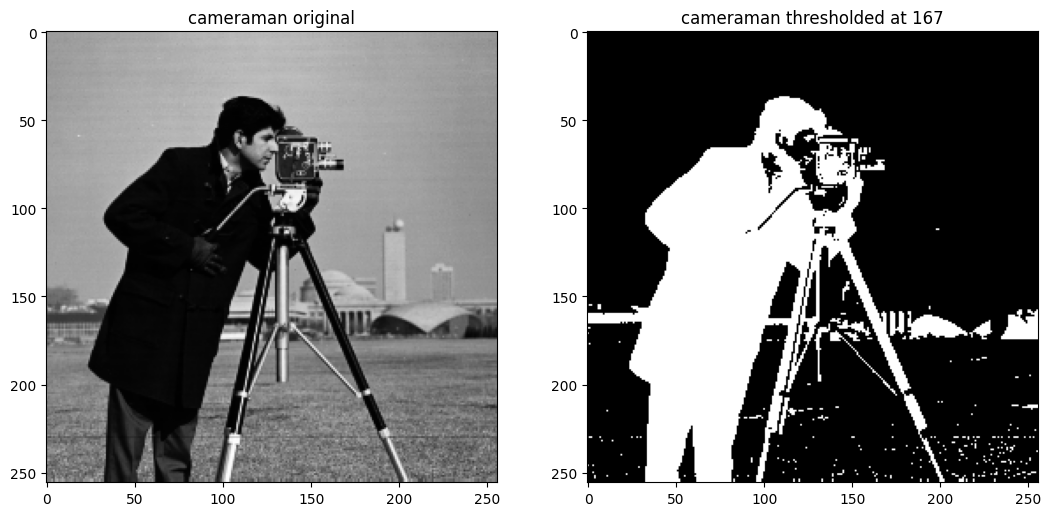

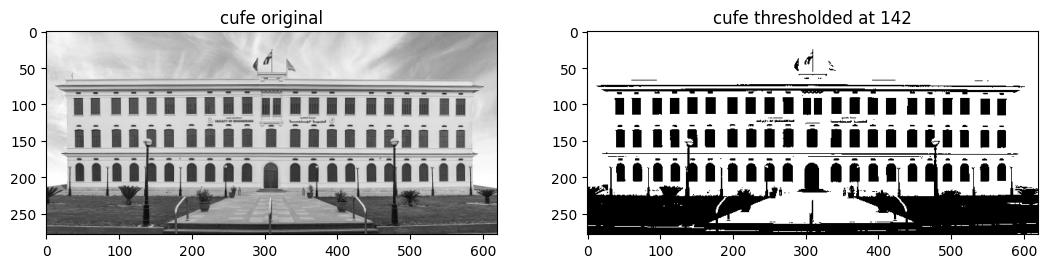

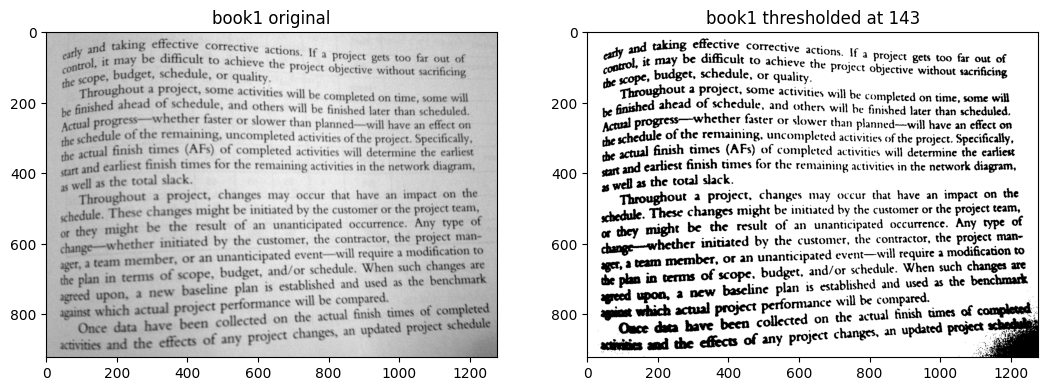

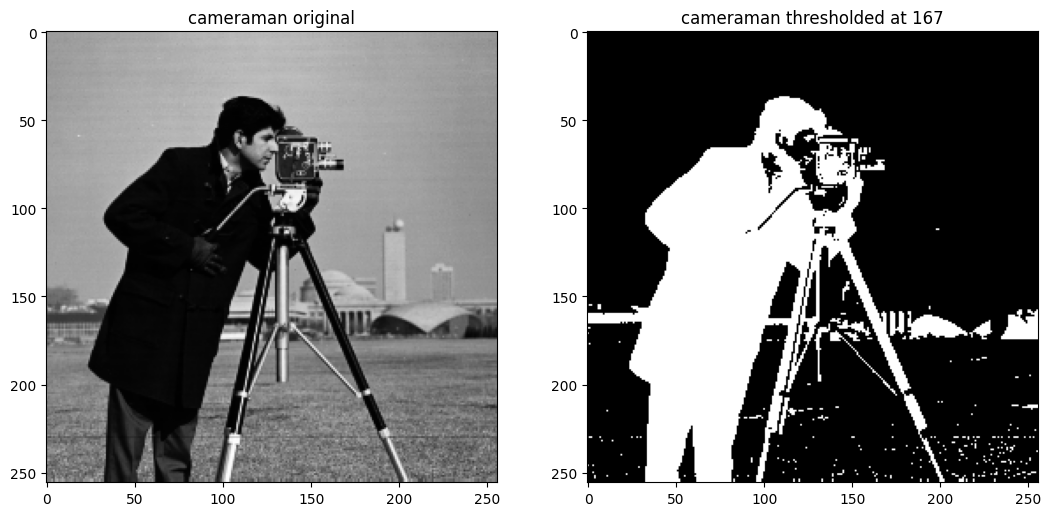

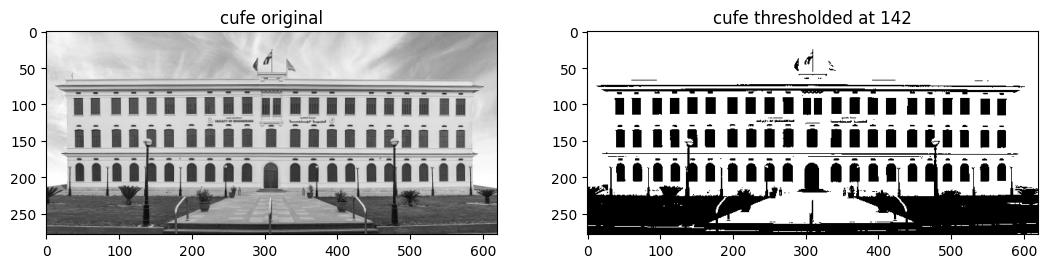

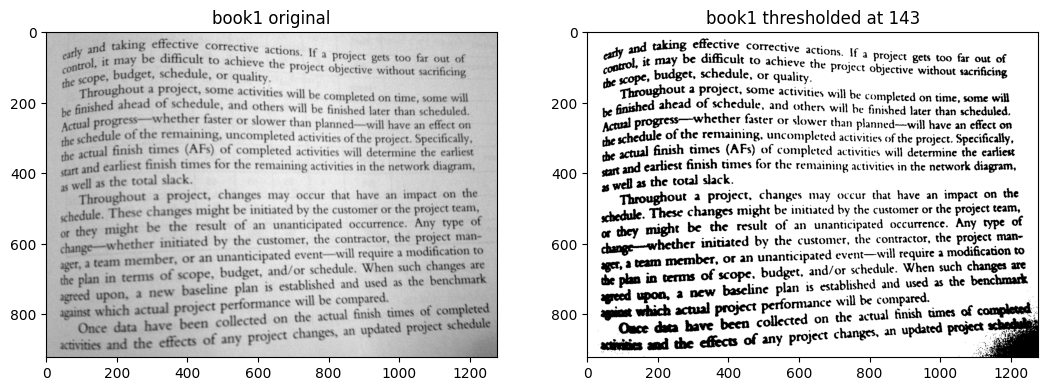

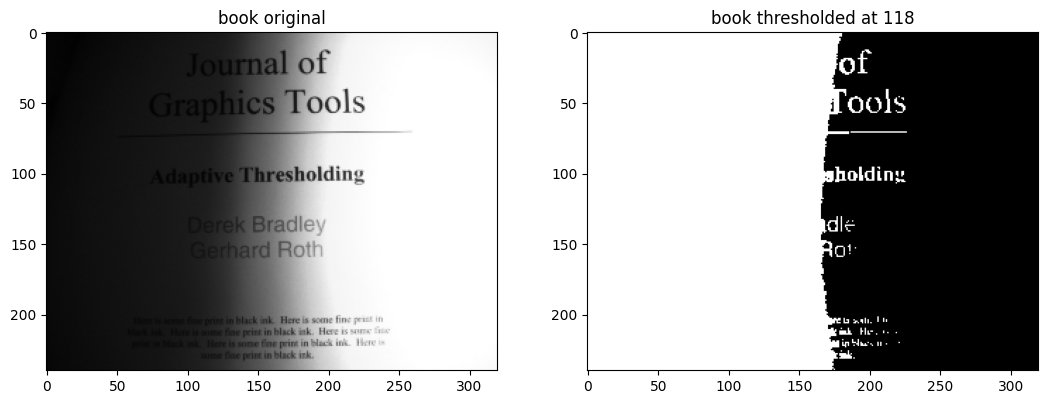

In [8]:
# Test the thresholding on the specified images
images = ['cameraman', 'cufe', 'book1', 'book']

for img_name in images:
    img = io.imread(img_name + ".png", as_gray=True)
    threshold = getThreshold(img)
    # Pixels < threshold -> 0, else 255
    binary_img = np.where(img * 255 < threshold, 0, 255).astype(np.uint8)
    show_images([img, binary_img], [f'{img_name} original', f'{img_name} thresholded at {threshold}'])

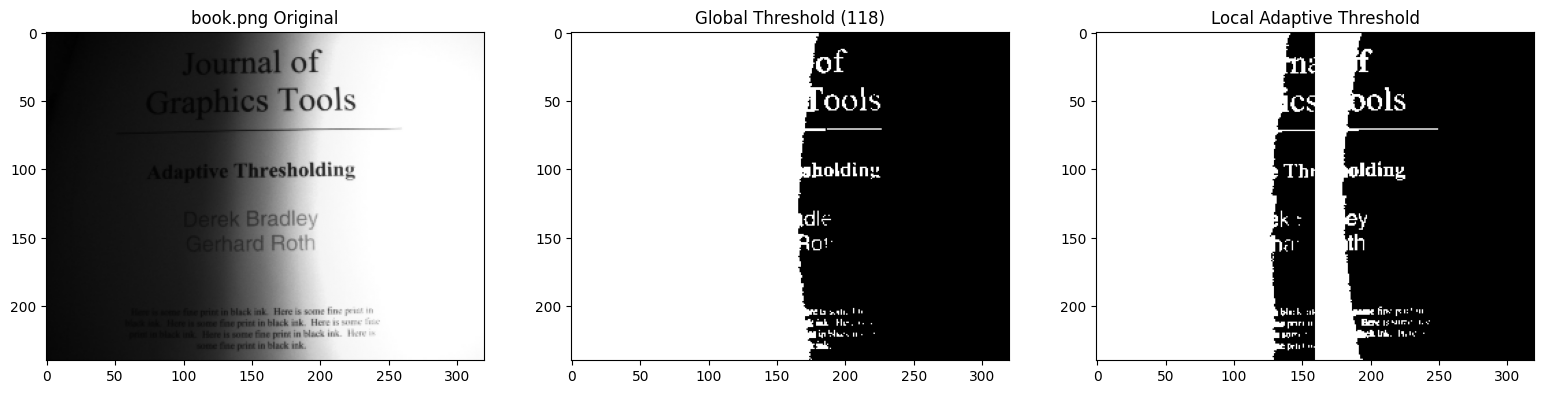

In [9]:
# Experiment 2: Local adaptive thresholding on "book.png"
book_img = io.imread('book.png', as_gray=True)

# 1. Original image
# 2. Global thresholded
global_threshold = getThreshold(book_img)
global_binary = np.where(book_img * 255 < global_threshold, 0, 255).astype(np.uint8)

# Partition into four quarters
h, w = book_img.shape
h_half, w_half = h // 2, w // 2

quarters = [
    book_img[:h_half, :w_half],
    book_img[:h_half, w_half:],
    book_img[h_half:, :w_half],
    book_img[h_half:, w_half:]
]

# Apply local threshold on each quarter
local_binary_quarters = []
for quarter in quarters:
    local_thresh = getThreshold(quarter)
    local_binary = np.where(quarter * 255 < local_thresh, 0, 255).astype(np.uint8)
    local_binary_quarters.append(local_binary)

# Gather the four quarters together
local_binary = np.zeros_like(book_img, dtype=np.uint8)
local_binary[:h_half, :w_half] = local_binary_quarters[0]
local_binary[:h_half, w_half:] = local_binary_quarters[1]
local_binary[h_half:, :w_half] = local_binary_quarters[2]
local_binary[h_half:, w_half:] = local_binary_quarters[3]

show_images([book_img, global_binary, local_binary],
            ['book.png Original', f'Global Threshold ({global_threshold})', 'Local Adaptive Threshold'])

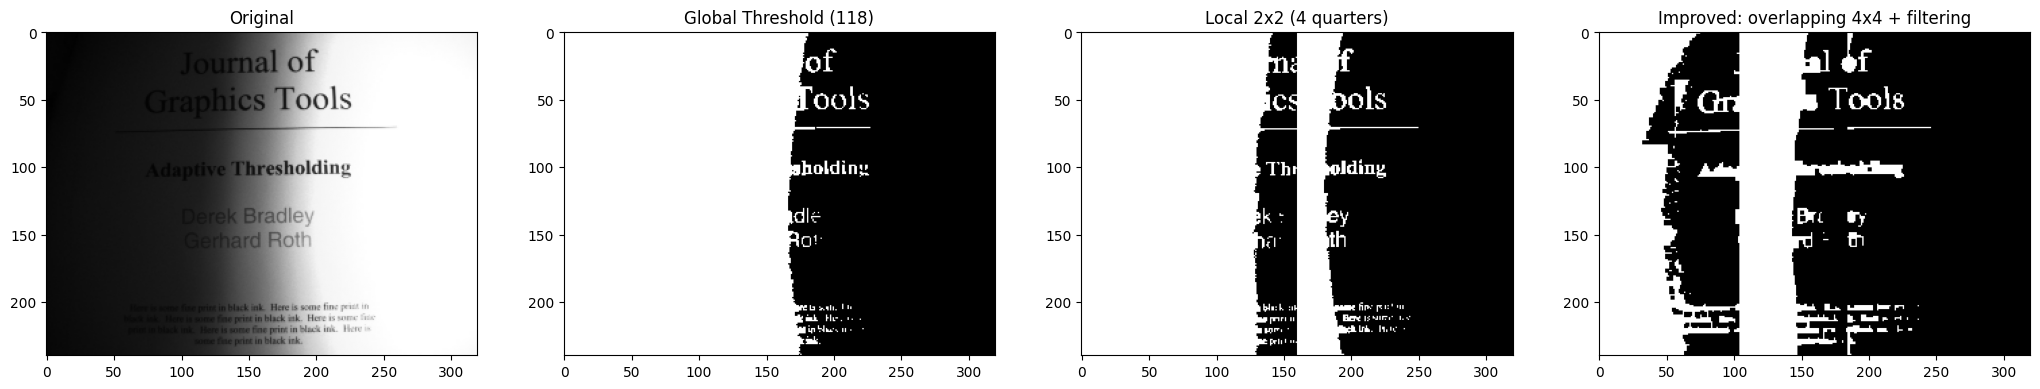

In [ ]:
# Experiment 3 (Bonus): Improve segmentation with overlapping adaptive blocks + post-processing
from scipy.ndimage import median_filter
from skimage.morphology import binary_closing

# Reuse global threshold result
global_threshold = getThreshold(book_img)
global_binary = np.where(book_img * 255 < global_threshold, 0, 255).astype(np.uint8)

h, w = book_img.shape
rows, cols = 4, 4  # smaller blocks -> finer adaptation
block_h, block_w = h // rows, w // cols
overlap = 24  # pixels to overlap to avoid seams

accumulator = np.zeros((h, w), dtype=np.float64)
weights = np.zeros((h, w), dtype=np.float64)

for row in range(rows):
    for col in range(cols):
        r0 = max(0, row * block_h - overlap)
        r1 = min(h, (row + 1) * block_h + overlap)
        c0 = max(0, col * block_w - overlap)
        c1 = min(w, (col + 1) * block_w + overlap)

        block = book_img[r0:r1, c0:c1]
        if block.size == 0:
            continue

        block_thresh = getThreshold(block)
        block_binary = np.where(block * 255 < block_thresh, 0, 255).astype(np.float64)

        accumulator[r0:r1, c0:c1] += block_binary
        weights[r0:r1, c0:c1] += 1

# Averaging overlapping regions
improved_local_binary = np.where(weights > 0, accumulator / weights, 0)
improved_local_binary = (improved_local_binary >= 128).astype(np.uint8) * 255

# Closing
improved_local_binary = binary_closing((improved_local_binary == 255), footprint=np.ones((3, 3))).astype(np.uint8) * 255

show_images(
    [book_img, global_binary, local_binary, improved_local_binary],
    ['Original',f'Global Threshold ({global_threshold})','Local 2x2 (4 quarters)','Improved: overlapping 4x4 + filtering']
)